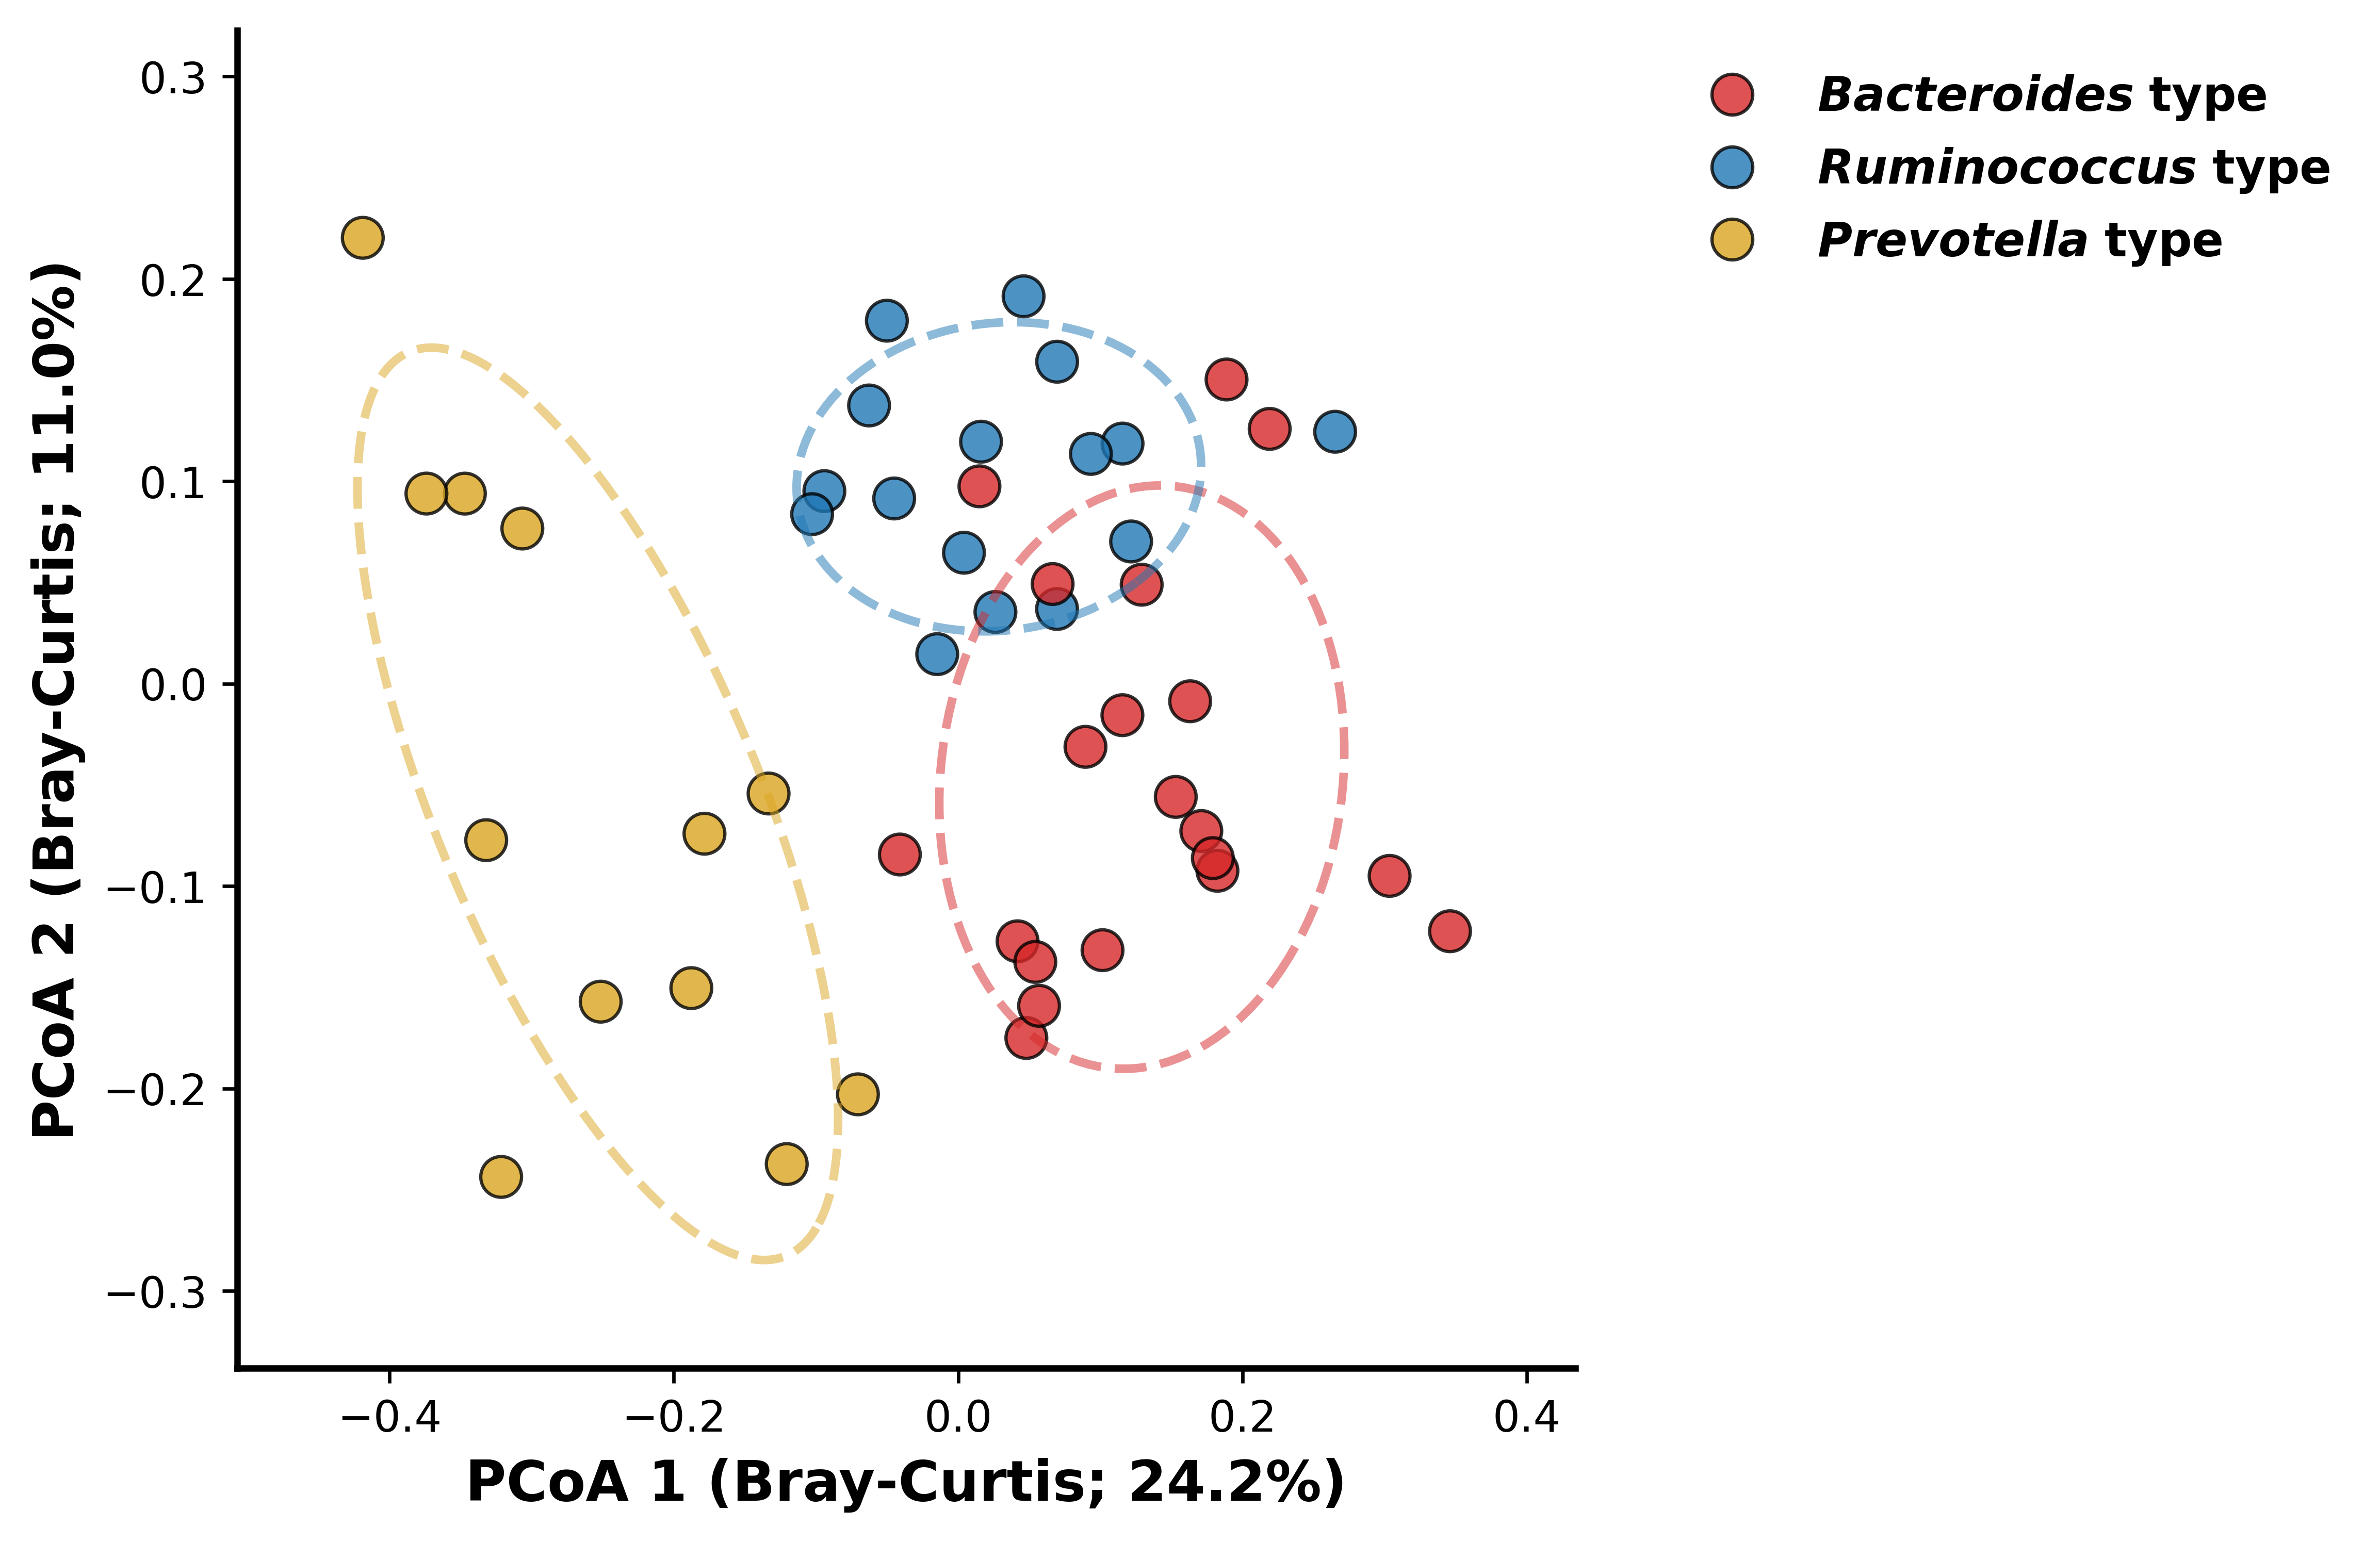

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import statsmodels.stats.multitest as multitest
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. Global Page and Font Settings (Nature Format)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.bf'] = 'Arial:italic:bold'
plt.rcParams['mathtext.tt'] = 'Arial:bold'
plt.rcParams['mathtext.it'] = 'Arial:italic'

# ==========================================
# Part A: Enterotype Clustering on FEC (S6a)
# ==========================================
df_16s = pd.read_csv('(KULFFI)_16S_Genus_level.csv')
tax_cols = [c for c in df_16s.columns if 'd__Bacteria' in c or 'd__Archaea' in c]

df_fec = df_16s[df_16s['Feature'] == 'FEC'].copy()
df_rel = df_fec.copy()
df_rel[tax_cols] = df_rel[tax_cols].div(df_rel[tax_cols].sum(axis=1), axis=0) * 100

def jensen_shannon_distance(p, q):
    m = 0.5 * (p + q)
    return np.sqrt(0.5 * (stats.entropy(p, m) + stats.entropy(q, m)))

p_matrix = df_rel[tax_cols].fillna(0).values / 100.0
p_matrix = p_matrix + 1e-9
p_matrix = p_matrix / p_matrix.sum(axis=1, keepdims=True)

n_samples = p_matrix.shape[0]
js_dist = np.zeros((n_samples, n_samples))
for i in range(n_samples):
    for j in range(i+1, n_samples):
        js = jensen_shannon_distance(p_matrix[i], p_matrix[j])
        js_dist[i, j] = js
        js_dist[j, i] = js

# PAM clustering (k=3)
np.random.seed(42)
medoids = np.random.choice(n_samples, 3, replace=False)
for _ in range(20):
    labels = np.argmin(js_dist[:, medoids], axis=1)
    new_medoids = np.copy(medoids)
    for i in range(3):
        cluster_indices = np.where(labels == i)[0]
        if len(cluster_indices) > 0:
            cost = np.sum(js_dist[cluster_indices][:, cluster_indices], axis=0)
            new_medoids[i] = cluster_indices[np.argmin(cost)]
    if np.array_equal(medoids, new_medoids):
        break
    medoids = new_medoids

df_rel['Enterotype_PAM'] = labels

bac_col = [c for c in tax_cols if 'g__Bacteroides' in c][0]
pre_cols = [c for c in tax_cols if 'f__Prevotellaceae' in c]
rum_cols = [c for c in tax_cols if 'f__Ruminococcaceae' in c]

means = [(i, df_rel[df_rel['Enterotype_PAM'] == i][bac_col].mean(),
          df_rel[df_rel['Enterotype_PAM'] == i][pre_cols].sum(axis=1).mean(),
          df_rel[df_rel['Enterotype_PAM'] == i][rum_cols].sum(axis=1).mean()) for i in range(3)]

pre_idx = sorted(means, key=lambda x: x[2], reverse=True)[0][0]
rum_idx = sorted([m for m in means if m[0] != pre_idx], key=lambda x: x[3], reverse=True)[0][0]
bac_idx = [m[0] for m in means if m[0] not in [pre_idx, rum_idx]][0]

cluster_map = {bac_idx: 'Bacteroides type', pre_idx: 'Prevotella type', rum_idx: 'Ruminococcus type'}
df_rel['Enterotype'] = df_rel['Enterotype_PAM'].map(cluster_map)

bc_dist = pdist(df_rel[tax_cols].fillna(0), metric='braycurtis')
D = squareform(bc_dist)
n = D.shape[0]
J = np.ones((n, n)) / n
I = np.eye(n)
B = (I - J).dot(-0.5 * D**2).dot(I - J)
eigenvalues, eigenvectors = np.linalg.eigh(B)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[idx], eigenvectors[:, idx]

perc = eigenvalues / np.sum(np.maximum(eigenvalues, 0)) * 100
pcoa_res = eigenvectors[:, :2] * np.sqrt(np.maximum(eigenvalues[:2], 0))
df_rel['PCoA1'], df_rel['PCoA2'] = pcoa_res[:, 0], pcoa_res[:, 1]

palette_et = {'Bacteroides type': '#d62728', 'Prevotella type': '#DAA520', 'Ruminococcus type': '#1f77b4'}

def confidence_ellipse(x, y, ax, n_std=1.5, facecolor='none', **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor=facecolor, **kwargs)
    scale_x, scale_y = np.sqrt(cov[0, 0]) * n_std, np.sqrt(cov[1, 1]) * n_std
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(7, 6), dpi=600)
sns.scatterplot(data=df_rel, x='PCoA1', y='PCoA2', hue='Enterotype', palette=palette_et, s=90, edgecolor='k', alpha=0.8, ax=ax)

for et in ['Bacteroides type', 'Prevotella type', 'Ruminococcus type']:
    x, y = df_rel[df_rel['Enterotype'] == et]['PCoA1'].values, df_rel[df_rel['Enterotype'] == et]['PCoA2'].values
    if len(x) > 2:
        confidence_ellipse(x, y, ax, n_std=1.5, edgecolor=palette_et[et], linewidth=2, linestyle='--', alpha=0.5)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
x_range = x_max - x_min
y_range = y_max - y_min
max_range = max(x_range, y_range)

x_center = (x_max + x_min) / 2
y_center = (y_max + y_min) / 3

ax.set_xlim(x_center - max_range / 2 - 0.05, x_center + max_range / 2 + 0.05)
ax.set_ylim(y_center - max_range / 3 - 0.05, y_center + max_range / 3 + 0.05)
ax.set_box_aspect(1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.xlabel(f'PCoA 1 (Bray-Curtis; {perc[0]:.1f}%)', fontsize=13, fontweight='bold')
plt.ylabel(f'PCoA 2 (Bray-Curtis; {perc[1]:.1f}%)', fontsize=13, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
new_labels = [r'$\mathbf{' + l.split()[0] + '}$ ' + r'$\mathtt{' + l.split()[1] + '}$' for l in labels]
ax.legend(handles, new_labels, title='', frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('Supplementary_Figure_S6a.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()

# ==========================================
# Part B: Delta SCFA response grouped by Enterotypes (S6b)
# ==========================================
df_butyrate = pd.read_csv('Butyrate(mM).csv')
df_propionate = pd.read_csv('Propionate(mM).csv')
if 'KULFFI' in df_butyrate.columns: df_butyrate = df_butyrate.set_index('KULFFI')
if 'KULFFI' in df_propionate.columns: df_propionate = df_propionate.set_index('KULFFI')

subject_to_et = dict(zip(df_rel['Cluster'], df_rel['Enterotype']))

def get_delta_data(df_metabolite, substrate_name):
    actual_sub_name = 'Resistant maltodextrin' if substrate_name == 'RMD' else substrate_name
    actual_sub_name = 'Resistant starch' if actual_sub_name == 'RS' else actual_sub_name
    subjects = [col for col in df_metabolite.columns if str(col).startswith('HS-')]

    ctrl_mask = df_metabolite.index.astype(str).str.contains('Control', case=False, na=False)
    if not ctrl_mask.any(): ctrl_mask = df_metabolite.iloc[:, 0].astype(str).isin(['0', '000'])
    ctrl_vals = pd.to_numeric(df_metabolite.loc[ctrl_mask, subjects].iloc[0], errors='coerce')

    sub_mask = df_metabolite.index.astype(str).str.contains(actual_sub_name, case=False, na=False)
    if not sub_mask.any(): sub_mask = df_metabolite.iloc[:, 0].astype(str).str.contains(actual_sub_name, case=False, na=False)

    if not sub_mask.any(): return pd.DataFrame()
    sub_vals = pd.to_numeric(df_metabolite.loc[sub_mask, subjects].iloc[0], errors='coerce')
    delta_vals = sub_vals - ctrl_vals

    data = []
    for subj in subjects:
        if subj in subject_to_et and not pd.isna(delta_vals[subj]):
            data.append({'Subject': subj, 'Enterotype': subject_to_et[subj], 'Delta': delta_vals[subj]})
    return pd.DataFrame(data)

panels = [
    (get_delta_data(df_propionate, 'RMD'), 'RMD', r'$\Delta$ Propionate (mM)'),
    (get_delta_data(df_propionate, 'RS'), 'RS', r'$\Delta$ Propionate (mM)'),
    (get_delta_data(df_propionate, 'Mannose'), 'Mannose', r'$\Delta$ Propionate (mM)'),
    (get_delta_data(df_butyrate, 'Inulin'), 'Inulin', r'$\Delta$ Butyrate (mM)'),
    (get_delta_data(df_butyrate, 'Xylitol'), 'Xylitol', r'$\Delta$ Butyrate (mM)'),
    (get_delta_data(df_butyrate, 'Erythritol'), 'Erythritol', r'$\Delta$ Butyrate (mM)')
]

et_order = ['Bacteroides type', 'Ruminococcus type', 'Prevotella type']

et_labels = [r'$\mathbf{Bacteroides}$' + '\n' + r'$\mathtt{type}$',
             r'$\mathbf{Ruminococcus}$' + '\n' + r'$\mathtt{type}$',
             r'$\mathbf{Prevotella}$' + '\n' + r'$\mathtt{type}$']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=600)
axes = axes.flatten()

p_values = []
valid_panels = []
for df_plot, title, ylabel in panels:
    groups = [df_plot[df_plot['Enterotype'] == et]['Delta'].dropna() for et in et_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) > 1:
        _, pval = stats.kruskal(*groups)
        p_values.append(pval)
        valid_panels.append((df_plot, title, ylabel, pval))

# FDR Correction
_, q_values, _, _ = multitest.multipletests(p_values, alpha=0.05, method='fdr_bh')

for i, (df_plot, title, ylabel, pval) in enumerate(valid_panels):
    ax = axes[i]
    qval = q_values[i]

    sns.boxplot(data=df_plot, x='Enterotype', y='Delta', order=et_order, ax=ax,
                palette=palette_et, width=0.5, showfliers=False, linewidth=1.5, boxprops=dict(alpha=0.6))

    sns.stripplot(data=df_plot, x='Enterotype', y='Delta', order=et_order, ax=ax,
                  palette=palette_et, size=6, jitter=True, alpha=0.9, edgecolor='k', linewidth=1)

    q_str = "< 0.001" if qval < 0.001 else f"= {qval:.3f}"

    ax.set_title(f'$\\mathtt{{{title}}}$\n$\\mathit{{P}}$ = {pval:.3f}, $\\mathit{{q}}$ {q_str}', fontsize=14, fontweight='normal')

    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5)

    ax.set_xticks(range(len(et_labels)))
    ax.set_xticklabels(et_labels, fontsize=12, fontweight='normal')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout(rect=[0, 0, 1, 1], w_pad=2.0, h_pad=2.0)
plt.savefig('Supplementary_Figure_S6b.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()